In [30]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [31]:
import torch
torch.cuda.is_available()

True

In [32]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy
from keras.datasets import mnist

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
def build_model(activation: str = 'relu'):
  model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(units=128, activation=activation),
    Dense(128, activation=activation),
    Dense(128, activation=activation),
    Dense(10, activation='softmax'), #10 categories of dogs
    # Dense(1,activation='linear'), # 1 stock price 
    # Dense(1, activation='sigmoid') # 1 "boolean"
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


  

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('x_train.shape: ', x_train.shape)
print('y_train.shape: ', y_train.shape)
print('x_test.shape: ', x_test.shape)
print('y_test.shape: ', y_test.shape)

x_train.shape:  (60000, 28, 28)
y_train.shape:  (60000,)
x_test.shape:  (10000, 28, 28)
y_test.shape:  (10000,)


In [36]:


model.fit(
  x_train, 
  y_train,
  batch_size=1024,
  epochs=10,
  validation_split=0.2
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5995 - loss: 6.0239 - val_accuracy: 0.7309 - val_loss: 4.1256
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7653 - loss: 3.4362 - val_accuracy: 0.8110 - val_loss: 2.7244
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8207 - loss: 2.6245 - val_accuracy: 0.8289 - val_loss: 2.4861
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8345 - loss: 2.4377 - val_accuracy: 0.8330 - val_loss: 2.3786
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8437 - loss: 2.2992 - val_accuracy: 0.8435 - val_loss: 2.2503
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8525 - loss: 2.1962 - val_accuracy: 0.8439 - val_loss: 2.2313
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8544 - loss: 2.1568 - val_accuracy: 0.8508 - val_loss: 2.1609
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8594 - loss: 2.0991 - val_accuracy: 0.8528 - val_loss:

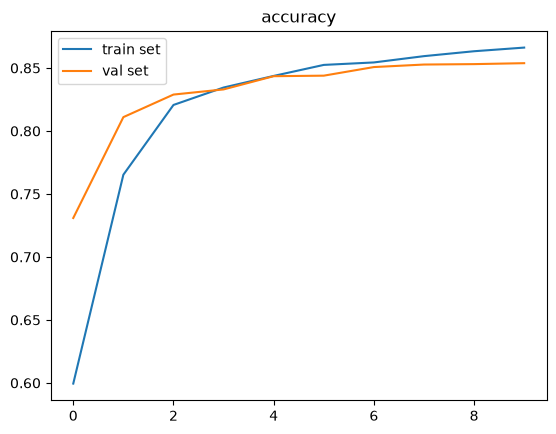

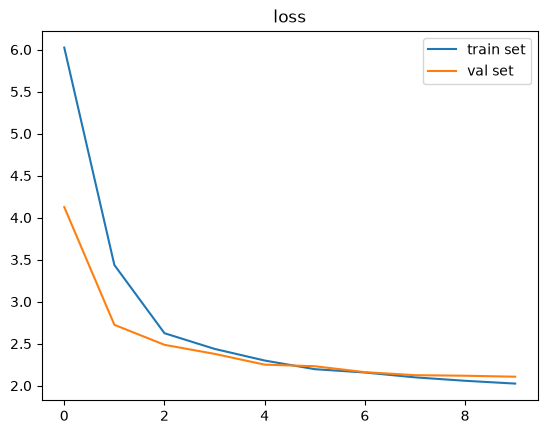

In [37]:
logs = model.history.history
plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['accuracy'], label="train set")
plt.plot(logs['val_accuracy'], label="val set")
plt.legend()
plt.title('accuracy')
plt.show()

plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['loss'], label="train set")
plt.plot(logs['val_loss'], label="val set")
plt.legend()
plt.title('loss')
plt.show()

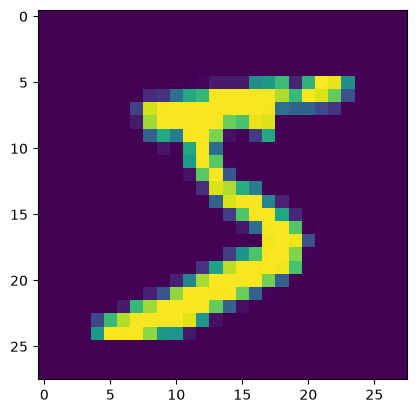

In [38]:
plt.imshow(x_train[0])

In [39]:
x_train[0].ravel() # == Flatten()  (pixel values of the first image)

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [40]:
y_pred_proba = model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 8, ..., 4, 5, 6], shape=(10000,))

In [41]:
y_pred == y_test

array([ True,  True, False, ...,  True,  True,  True], shape=(10000,))

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.00      0.00      0.00      1135
           2       0.94      0.95      0.94      1032
           3       0.81      0.96      0.88      1010
           4       0.97      0.96      0.96       982
           5       0.93      0.94      0.93       892
           6       0.94      0.97      0.96       958
           7       0.71      0.97      0.82      1028
           8       0.62      0.95      0.75       974
           9       0.94      0.93      0.94      1009

    accuracy                           0.85     10000
   macro avg       0.78      0.86      0.82     10000
weighted avg       0.77      0.85      0.80     10000



/home/pinch/projects/deeplearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pinch/projects/deeplearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pinch/projects/deeplearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

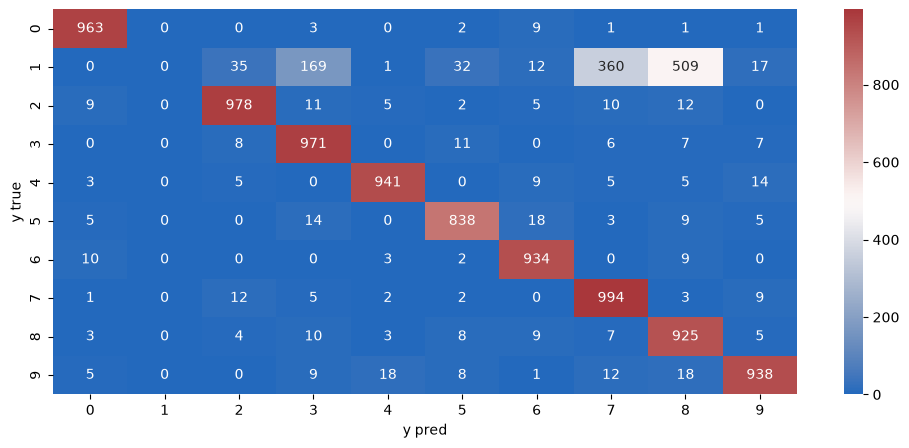

In [50]:
crosstab = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,5))
sns.heatmap(crosstab, cmap="vlag", annot=True, fmt='d')
plt.xlabel('y pred')
plt.ylabel('y true')
plt.show()

In [49]:
np.random.seed(1)
np.random.randint(0,10,2)
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)
print('x_train: ', x_train.shape)
print('x_val: ', x_val.shape)


x_train:  (48000, 28, 28)
x_val:  (12000, 28, 28)
